In [1]:
import platform
import kagglehub as kh
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split , KFold , cross_validate , RandomizedSearchCV
from IPython.display import display
from helper_utils import data_split
from sklearn.compose import ColumnTransformer , TransformedTargetRegressor
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet 
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.ensemble import ExtraTreesRegressor , RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib
import os
from pathlib import Path
from scipy.stats import randint , uniform , loguniform
from AmesFeatures import *
from sklearn.metrics import r2_score , mean_absolute_error , root_mean_squared_error , mean_squared_error

pd.set_option('display.max_rows',None)
display(platform.python_version())

/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'3.14.4'

In [2]:
TARGET='SalePrice'
data_path=Path('./data/AmesHousing.csv')
if not data_path.exists():
    print("Data not found..\n Downloading the dataset")
    path=kh.dataset_download("shashanknecrothapa/ames-housing-dataset",output_dir="./data",force_download=True)

raw = pd.read_csv(data_path)
if TARGET not in raw:
    raise ValueError(f"Expected target {TARGET!r} was not found.")
if raw[TARGET].isna().any():
    raise ValueError("Target contains missing values; define a target policy before modeling.")

audit = pd.Series({
    "Rows": len(raw),
    "Columns": raw.shape[1],
    "Numeric columns": raw.select_dtypes(include=np.number).shape[1],
    "Categorical columns": raw.select_dtypes(exclude=np.number).shape[1],
    "Exact duplicate rows": int(raw.duplicated().sum()),
    "Missing targets": int(raw[TARGET].isna().sum()),
}, name="value")
display(audit.to_frame())
display(raw.head(10))

,value
Rows,2930
Columns,82
Numeric columns,39
Categorical columns,43
Exact duplicate rows,0
Missing targets,0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [3]:
X_train,X_test,Y_Train,Y_Test=data_split(raw)

In [4]:
# Drop the well-documented Ames anomalies (huge homes that sold far below
# trend) from the TRAINING set only. Never touch X_test/Y_Test this way -
# that would silently inflate reported test metrics.
X_train, Y_Train = drop_known_outliers(X_train, Y_Train)
print(f"Training rows after outlier removal: {len(X_train)}")

Training rows after outlier removal: 2342


In [5]:
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

estimators={
    'Lasso':{
        'model':Lasso(),
        'parameters':{
            'regressor__model__alpha':loguniform(a=0.0001, b=1.0),
            "regressor__model__max_iter": [5000, 10000, 20000]
        }
    },
    'Ridge':{
        'model':Ridge(),
        'parameters' : {
            'regressor__model__alpha':loguniform(a=0.0001, b=1.0),
            "regressor__model__max_iter": [5000, 10000, 20000]
        }
    },
    'ElasticNet' :{
        'model':ElasticNet(),
        'parameters':{
            'regressor__model__alpha':loguniform(a=0.0001, b=1.0),
            'regressor__model__l1_ratio':loguniform(a=0.0001, b=1.0),
            "regressor__model__max_iter": [5000, 10000, 20000]
        }
    },
    'ExtraTreesRegressor':{
        'model':ExtraTreesRegressor(random_state=42),
        'parameters':{
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 5, 10, 20, 30, 50],
            "regressor__model__min_samples_split": [2, 5, 10, 20],
            "regressor__model__min_samples_leaf": [1, 2, 4, 8],
            "regressor__model__max_features": [1.0, "sqrt", "log2"],
            "regressor__model__bootstrap": [True, False]
        }
    },
    'RandomForestRegressor':{
        'model':RandomForestRegressor(random_state=42),
        'parameters':{
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 5, 10, 20, 30, 50],
            "regressor__model__min_samples_split": [2, 5, 10, 20],
            "regressor__model__min_samples_leaf": [1, 2, 4, 8],
            "regressor__model__max_features": [1.0, "sqrt", "log2"],
            "regressor__model__bootstrap": [True, False]
        }
    }

}

In [6]:
# forming a baseline with LinearRegression
model=build_model_pipeline(LinearRegression(),scale_numeric=True,use_log_target=True)
cv=KFold(n_splits=5,shuffle=True,random_state=42)
results=cross_validate(
    estimator=model,
    X=X_train,
    y=Y_Train,
    cv=cv,
    scoring=scoring
)
pd.DataFrame(
    {
        'Training time':[results['fit_time'].mean(0)],
        'Validating time':[results['score_time'].mean(0)],
        'R2 score':[results['test_r2'].mean(0)],
        'MSE score':[results['test_mse'].mean(0)],
        'MAE score':[results['test_mae'].mean(0)],
        'RMSE score':[results['test_rmse'].mean(0)]
    }
)

,Training time,Validating time,R2 score,MSE score,MAE score,RMSE score
0,0.266684,0.029908,0.931442,-3.992526e+08,-13411.834705,-19960.295545


In [7]:
models={}
cv_scores={}  # cross-validated RMSE per estimator, from the search itself
for i in estimators.keys():
    search=RandomizedSearchCV(
        estimator=build_model_pipeline(estimators[i]['model'],scale_numeric=True,use_log_target=True),
        param_distributions=estimators[i]['parameters'],
        n_iter=30,
        cv=5,
        scoring=scoring,
        refit="rmse",
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train,Y_Train)
    models[i]=(search.best_estimator_)
    cv_scores[i]=-search.best_score_  # best_score_ is neg_rmse; flip sign to plain RMSE


/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.061807e+00, tolerance: 2.998e-02
  model = cd_fast.enet_coordinate_descent(
/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.273951e+00, tolerance: 3.014e-02
  model = cd_fast.enet_coordinate_descent(
/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did

In [8]:
data={
    'model':[],
    'RMSE score':[],
    'MSE score':[],
    'MAE score':[],
    'R2 score':[]
}

# performance for train score
for i in models.keys():
    x=X_train
    y=Y_Train
    y_pred=models[i].predict(x)
    data['model'].append(i)
    data['R2 score'].append(r2_score(y,y_pred))
    data['RMSE score'].append(root_mean_squared_error(y,y_pred))
    data['MSE score'].append(mean_squared_error(y,y_pred))
    data['MAE score'].append(mean_absolute_error(y,y_pred))

train_statistics=pd.DataFrame(data)
display(train_statistics)

,model,RMSE score,MSE score,MAE score,R2 score
0,Lasso,17654.694802,3.116882e+08,11951.795213,0.947621
1,Ridge,17267.287889,2.981592e+08,11791.888505,0.949895
2,ElasticNet,17748.632048,3.150139e+08,11993.714901,0.947062
3,ExtraTreesRegressor,2748.828585,7.556059e+06,1499.421384,0.998730
4,RandomForestRegressor,12679.339875,1.607657e+08,8405.438416,0.972984


In [9]:
cv_comparison = pd.DataFrame({'model': list(cv_scores.keys()), 'CV RMSE': list(cv_scores.values())})
cv_comparison = cv_comparison.sort_values('CV RMSE').reset_index(drop=True)
display(cv_comparison)


,model,CV RMSE
0,Lasso,19351.101181
1,ElasticNet,19402.152643
2,Ridge,19631.217289
3,ExtraTreesRegressor,23442.703458
4,RandomForestRegressor,24693.133647


In [10]:
data={
    'model':[],
    'RMSE score':[],
    'MSE score':[],
    'MAE score':[],
    'R2 score':[]
}
# Select the best model by cross-validated RMSE (search.best_score_ per estimator),
# NOT by train_statistics - training score always favors whichever model overfits
# hardest, since nothing stops it from memorizing the training set.
best_name = min(cv_scores, key=cv_scores.get)
best_model = models[best_name]

# performance on the untouched held-out test set
x=X_test
y=Y_Test
y_pred=models[best_name].predict(x)
data['model'].append(best_name)
data['R2 score'].append(r2_score(y,y_pred))
data['RMSE score'].append(root_mean_squared_error(y,y_pred))
data['MSE score'].append(mean_squared_error(y,y_pred))
data['MAE score'].append(mean_absolute_error(y,y_pred))

test_statistics=pd.DataFrame(data)
display(test_statistics)


,model,RMSE score,MSE score,MAE score,R2 score
0,Lasso,29913.791027,8.948349e+08,14342.816755,0.88839


In [11]:
# Save the model selected above (by cross-validated RMSE) for deployment.
# model.pkl is a single self-contained sklearn Pipeline: feature engineering,
# encoding, scaling, and the trained model all in one object. A frontend only
# needs this file + AmesFeatures.py (for the AmesFeatureEngineer class) and
# can call model.predict(raw_dataframe) directly - no separate preprocessing
# step needed on the frontend side.
print(f"Selected model (by CV RMSE): {best_name}")

joblib.dump(best_model, 'model.pkl')
print("Saved model.pkl")

Selected model (by CV RMSE): Lasso
Saved model.pkl


## Model explainability (SHAP)

`shap.Explainer` auto-detects the underlying model type (linear, tree, etc.)
and picks an appropriate exact/fast explainer, so this works regardless of
which model won the comparison above.

In [12]:
import shap

fitted_pipeline = best_model.regressor_  # inner Pipeline inside TransformedTargetRegressor
preprocessing = fitted_pipeline.named_steps['preprocessing']
inner_model = fitted_pipeline.named_steps['model']

feature_names = preprocessing.named_steps['column_transform'].get_feature_names_out()
feature_names = [f.split('__', 1)[-1] for f in feature_names]  # strip ColumnTransformer prefixes

X_train_transformed = preprocessing.transform(X_train)
X_test_transformed = preprocessing.transform(X_test)

background = shap.sample(X_train_transformed, 100, random_state=42)
explainer = shap.Explainer(inner_model, background, feature_names=feature_names)
shap_values = explainer(X_test_transformed[:100])

**Global**: which features move predictions most, across 100 test houses.

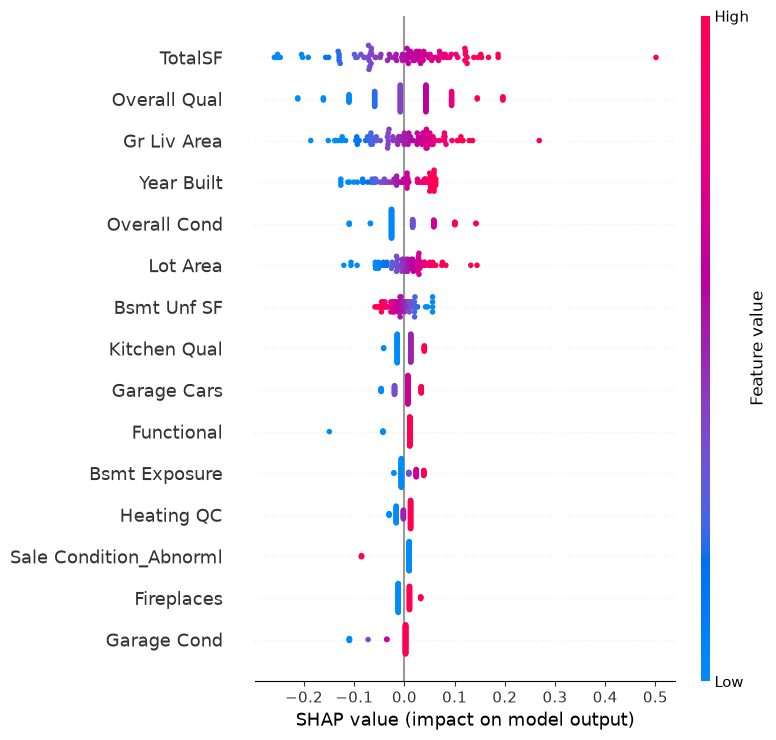

In [13]:
shap.summary_plot(shap_values, X_test_transformed[:100], feature_names=feature_names, max_display=15)

**Local**: why the model predicted what it did for one specific house.

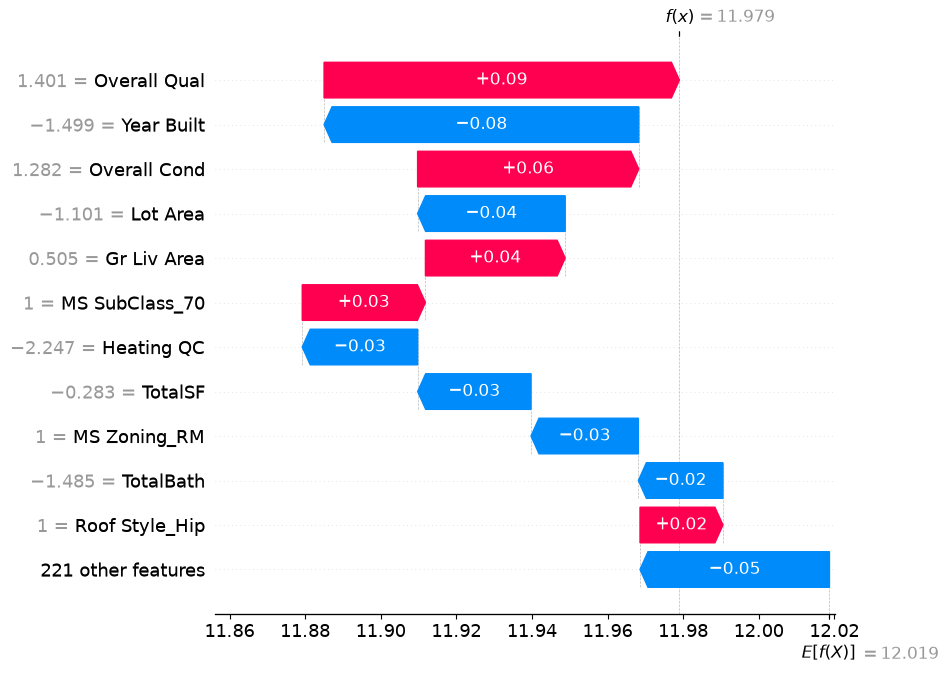

In [14]:
shap.plots.waterfall(shap_values[0], max_display=12)